# Data Cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("student_data.csv")

In [5]:
print("Original Dataset")
print(df)

Original Dataset
    Student_ID  Age  Gender  Attendance  Marks
0            1   18  Female        90.0   85.0
1            2   19    Male        85.0   78.0
2            3   20  Female         NaN   92.0
3            4   18    Male        88.0   76.0
4            5   21  Female        95.0   89.0
5            6   19    Male        85.0   78.0
6            6   19    Male        85.0   78.0
7            7   20  Female        92.0   95.0
8            8   18    Male         NaN   80.0
9            9   22  Female        98.0  300.0
10          10   19    Male        87.0   82.0
11          11   20  Female        91.0    NaN
12          12   18    Male        89.0   77.0
13          13   21  Female        94.0   88.0
14          14   20    Male        93.0   84.0
15          15   19  Female        90.0   81.0


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Student_ID    0
Age           0
Gender        0
Attendance    2
Marks         1
dtype: int64


In [7]:
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())
df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

In [8]:
df = df.drop_duplicates()

In [9]:
Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)
IQR = Q3 - Q1

In [10]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [11]:
df = df[(df['Marks'] >= lower) & (df['Marks'] <= upper)]

In [12]:
print("\nCleaned Dataset")
print(df)


Cleaned Dataset
    Student_ID  Age  Gender  Attendance      Marks
0            1   18  Female   90.000000  85.000000
1            2   19    Male   85.000000  78.000000
2            3   20  Female   90.142857  92.000000
3            4   18    Male   88.000000  76.000000
4            5   21  Female   95.000000  89.000000
5            6   19    Male   85.000000  78.000000
7            7   20  Female   92.000000  95.000000
8            8   18    Male   90.142857  80.000000
10          10   19    Male   87.000000  82.000000
11          11   20  Female   91.000000  97.533333
12          12   18    Male   89.000000  77.000000
13          13   21  Female   94.000000  88.000000
14          14   20    Male   93.000000  84.000000
15          15   19  Female   90.000000  81.000000


# Data Visualization

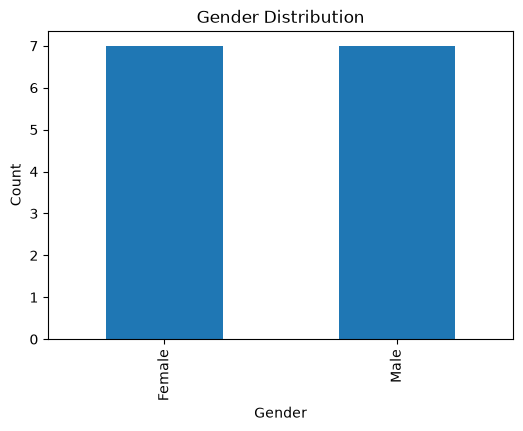

In [13]:
plt.figure(figsize=(6,4))
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

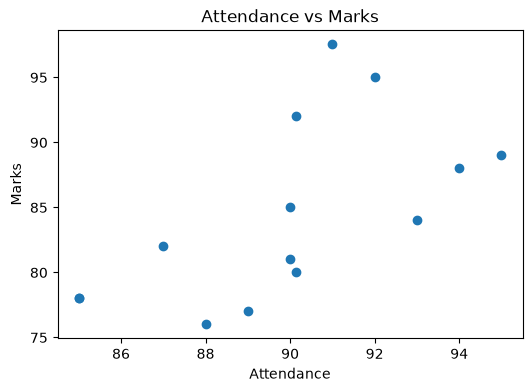

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(df['Attendance'], df['Marks'])
plt.title("Attendance vs Marks")
plt.xlabel("Attendance")
plt.ylabel("Marks")
plt.show()

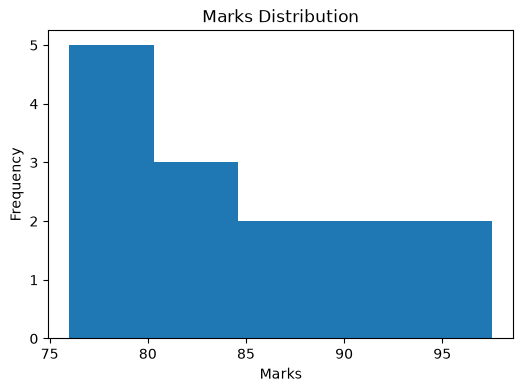

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['Marks'], bins=5)
plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()